## Data cleanup - normalized merging of expression data and quality-control of affinity datasets

In [ ]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats as st
from scipy import odr

# align expression datasets by median-matching (see methods for detailed explanation)

In [ ]:
# helper for consistent geno formatting
def load_with_geno(path, sep='\t', zpad=13):
    df = pd.read_csv(path, sep=sep)
    df['geno'] = df['geno'].astype(str).str.zfill(zpad)
    return df

ba4_1 = load_with_geno('../raw_datasets/affinity_expr_raw/Kds_Omi32a.tsv')
ba4_2 = load_with_geno('../raw_datasets/affinity_expr_raw/Kds_Omi32b.tsv')

ba1_1 = load_with_geno('../raw_datasets/affinity_expr_raw/Kds_Omi32d.tsv')
ba1_2 = load_with_geno('../raw_datasets/affinity_expr_raw/Kds_Omi32i.tsv')

wuhan_1 = load_with_geno('../raw_datasets/affinity_expr_raw/Kds_Omi32e.tsv')
wuhan_2 = load_with_geno('../raw_datasets/affinity_expr_raw/Kds_Omi32f.tsv')

psr_1 = load_with_geno('../raw_datasets/psr_raw/Kds_Omi32g.tsv')
psr_2 = load_with_geno('../raw_datasets/psr_raw/Kds_Omi32h.tsv')

In [38]:
ba4_merge = pd.merge(ba4_1,ba4_2,on='geno',suffixes=("_r1","_r2"))
ba1_merge = pd.merge(ba1_1,ba1_2,on='geno',suffixes=("_r1","_r2"))
wuhan_merge = pd.merge(wuhan_1,wuhan_2,on='geno',suffixes=("_r1","_r2"))
psr_merge = pd.merge(psr_1,psr_2,on='geno',suffixes=('_r1','_r2'))

ba4_merge['mean_expr'] = (ba4_merge['Mean fluorescence expression_r1']+ba4_merge['Mean fluorescence expression_r2'])/2
ba4_merge['SEM_expr'] = (ba4_merge['Mean fluorescence expression_r1']-ba4_merge['Mean fluorescence expression_r2']).abs()/2

wuhan_merge['mean_expr'] = (wuhan_merge['Mean fluorescence expression_r1']+wuhan_merge['Mean fluorescence expression_r2'])/2
wuhan_merge['SEM_expr'] = (wuhan_merge['Mean fluorescence expression_r1']-wuhan_merge['Mean fluorescence expression_r2']).abs()/2

psr_merge['mean_expr'] = (psr_merge['Mean fluorescence expression_r1']+psr_merge['Mean fluorescence expression_r2'])/2
psr_merge['SEM_expr'] = (psr_merge['Mean fluorescence expression_r1']-psr_merge['Mean fluorescence expression_r2']).abs()/2

In [ ]:
# 1) collect the 6 expressionreplicates
rep_series = {
    "ba4_r1":   ba4_merge["Mean fluorescence expression_r1"],
    "ba4_r2":   ba4_merge["Mean fluorescence expression_r2"],
    "wuhan_r1": wuhan_merge["Mean fluorescence expression_r1"],
    "wuhan_r2": wuhan_merge["Mean fluorescence expression_r2"],
    "psr_r1":   psr_merge["Mean fluorescence expression_r1"],
    "psr_r2":   psr_merge["Mean fluorescence expression_r2"],
}

# 2) compute per-replicate medians
medians = {name: s.median() for name, s in rep_series.items()}

# 3) choose a target median (median of the 6 runs)
target_median = np.median(list(medians.values()))

# 4) apply median-matching (shift) to each source df
ba4_merge["expr_r1_mednorm"] = ba4_merge["Mean fluorescence expression_r1"] + (target_median - medians["ba4_r1"])
ba4_merge["expr_r2_mednorm"] = ba4_merge["Mean fluorescence expression_r2"] + (target_median - medians["ba4_r2"])

wuhan_merge["expr_r1_mednorm"] = wuhan_merge["Mean fluorescence expression_r1"] + (target_median - medians["wuhan_r1"])
wuhan_merge["expr_r2_mednorm"] = wuhan_merge["Mean fluorescence expression_r2"] + (target_median - medians["wuhan_r2"])

psr_merge["expr_r1_mednorm"] = psr_merge["Mean fluorescence expression_r1"] + (target_median - medians["psr_r1"])
psr_merge["expr_r2_mednorm"] = psr_merge["Mean fluorescence expression_r2"] + (target_median - medians["psr_r2"])

# 5) now make a unified table keyed on geno
expr_merged = pd.DataFrame({
    "geno": ba4_merge["geno"],
    "ba4_expr_r1":   ba4_merge["expr_r1_mednorm"],
    "ba4_expr_r2":   ba4_merge["expr_r2_mednorm"],
    "wuhan_expr_r1": wuhan_merge["expr_r1_mednorm"],
    "wuhan_expr_r2": wuhan_merge["expr_r2_mednorm"],
    "psr_expr_r1":   psr_merge["expr_r1_mednorm"],
    "psr_expr_r2":   psr_merge["expr_r2_mednorm"],
})

# 6) average across the 6 normalized replicates
expr_cols = [
    "ba4_expr_r1", "ba4_expr_r2",
    "wuhan_expr_r1", "wuhan_expr_r2",
    "psr_expr_r1", "psr_expr_r2",
]

expr_merged["expr_mednorm_mean"] = expr_merged[expr_cols].mean(axis=1)

# 7) calculate SEM across the 6 runs
expr_merged["expr_mednorm_sem"] = expr_merged[expr_cols].std(axis=1, ddof=1) / np.sqrt(len(expr_cols))


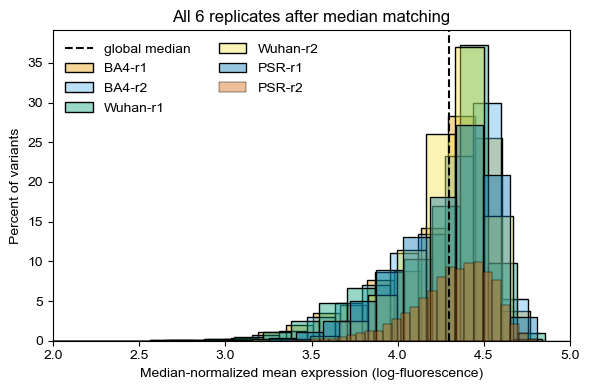

In [ ]:
# check all 6 normalized replicates
plt.figure(figsize=(6,4))

sns.histplot(ba4_merge["expr_r1_mednorm"],   stat="percent", bins=30, color="#E69F00", alpha=0.4, label="BA4-r1")
sns.histplot(ba4_merge["expr_r2_mednorm"],   stat="percent", bins=30, color="#56B4E9", alpha=0.4, label="BA4-r2")
sns.histplot(wuhan_merge["expr_r1_mednorm"], stat="percent", bins=30, color="#009E73", alpha=0.4, label="Wuhan-r1")
sns.histplot(wuhan_merge["expr_r2_mednorm"], stat="percent", bins=30, color="#F0E442", alpha=0.4, label="Wuhan-r2")
sns.histplot(psr_merge["expr_r1_mednorm"],   stat="percent", bins=30, color="#0072B2", alpha=0.4, label="PSR-r1")
sns.histplot(psr_merge["expr_r2_mednorm"],   stat="percent", bins=30, color="#D55E00", alpha=0.4, label="PSR-r2")

plt.axvline(expr_merged["expr_mednorm_mean"].median(), color="k", linestyle="--", label="global median")

plt.xlabel("Median-normalized mean expression (log-fluorescence)")
plt.ylabel("Percent of variants")
plt.title("All 6 replicates after median matching")
plt.legend(frameon=False, ncol=2)
plt.xlim(2,5)
plt.tight_layout()
plt.show()



Canvas size: 1 × 1 inches
Total figure size: 1.85 × 1.70 inches
At 2000 DPI: 3700 × 3400 pixels

✓ Figures saved successfully!


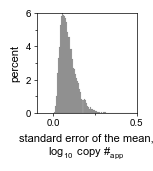


Combined SEM — median: 0.0839531812272076
Combined SEM — mean:   0.09641474126805286


In [ ]:
from matplotlib.gridspec import GridSpec

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'

CANVAS_WIDTH = 1
CANVAS_HEIGHT = 1

LEFT_MARGIN = 0.6
RIGHT_MARGIN = 0.25
TOP_MARGIN = 0.2
BOTTOM_MARGIN = 0.5

OUTPUT_DPI = 2000

fig_width = LEFT_MARGIN + CANVAS_WIDTH + RIGHT_MARGIN
fig_height = TOP_MARGIN + CANVAS_HEIGHT + BOTTOM_MARGIN

fig = plt.figure(figsize=(fig_width, fig_height))

gs = GridSpec(1, 1, figure=fig,
              left=LEFT_MARGIN/fig_width,
              right=(LEFT_MARGIN + CANVAS_WIDTH)/fig_width,
              top=1 - TOP_MARGIN/fig_height,
              bottom=BOTTOM_MARGIN/fig_height)

ax = fig.add_subplot(gs[0])

# SEM across 6 median-matched reps
sns.histplot(data=expr_merged['expr_mednorm_sem'], stat='percent', ax=ax,color='gray')

ax.set_xlabel('standard error of the mean,\n$\\log_{10}$ copy #$_{\\mathrm{app}}$', fontsize=8, labelpad=4)
ax.set_ylabel('percent', fontsize=8, labelpad=4)

ax.set_ylim(0, 6)
ax.set_yticks([0, 2, 4, 6])
ax.set_yticks([1, 3, 5], minor=True)

ax.set_xlim(-0.1, 0.5)
ax.set_xticks([0, 0.5])
ax.set_xticks([0.25], minor=True)

ax.tick_params(axis='both', which='major', labelsize=7, pad=2, length=2, width=0.5, direction='out')
ax.tick_params(axis='both', which='minor', length=1.5, width=0.5, direction='out')

ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

print(f'\nCanvas size: {CANVAS_WIDTH} × {CANVAS_HEIGHT} inches')
print(f'Total figure size: {fig_width:.2f} × {fig_height:.2f} inches')
print(f'At {OUTPUT_DPI} DPI: {int(fig_width * OUTPUT_DPI)} × {int(fig_height * OUTPUT_DPI)} pixels')

plt.savefig('expression_sixrep_sem.png', format='png', dpi=OUTPUT_DPI, bbox_inches='tight', transparent=True)
plt.savefig('expression_sixrep_sem.pdf', bbox_inches='tight', transparent=True)
print("\n✓ Figures saved successfully!")

plt.show()

print("\nCombined SEM — median:", expr_merged['expr_mednorm_sem'].median())
print("Combined SEM — mean:  ", expr_merged['expr_mednorm_sem'].mean())

# check outliers in the data - remove replicates with high SEM and low sequencing coverage across bins

In [ ]:
# stack all six replicate variant-fraction tables
all_cov = pd.concat([
    ba4_1[["geno", "median_variant_fraction"]],
    ba4_2[["geno", "median_variant_fraction"]],
    wuhan_1[["geno", "median_variant_fraction"]],
    wuhan_2[["geno", "median_variant_fraction"]],
    psr_1[["geno", "median_variant_fraction"]],
    psr_2[["geno", "median_variant_fraction"]],
], ignore_index=True)

#take the median across all datasets for each variant
cov_medians = all_cov.groupby("geno", as_index=False)["median_variant_fraction"].median()
cov_medians.rename(columns={"median_variant_fraction": "median_variant_fraction_global"}, inplace=True)

#merge into your combined expression table
expr_merged = expr_merged.merge(cov_medians, on="geno", how="left")


            geno  expr_mednorm_mean  expr_mednorm_sem  \
0  0000000000000           4.329135          0.072716   
1  0000000000001           4.396547          0.071945   
2  0000000000010           4.280882          0.143550   
3  0000000000011           4.334665          0.063902   
4  0000000000100           4.136578          0.101341   

   median_variant_fraction_global  
0                        0.000057  
1                        0.000020  
2                        0.000039  
3                        0.000149  
4                        0.000408  
Coverage median (global): 8.764681667201149e-05


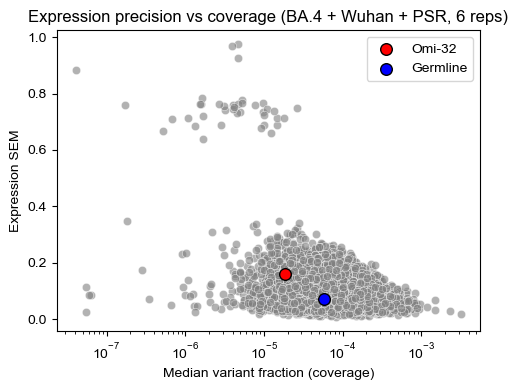

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))

# main scatter (gray points)
sns.scatterplot(
    data=expr_merged,
    x="median_variant_fraction_global",
    y="expr_mednorm_sem",
    color="gray",
    alpha=0.6,
    ax=ax
)

# highlight Omi-32 and Germline
omi = expr_merged[expr_merged["geno"] == "1111111111111"]
gl  = expr_merged[expr_merged["geno"] == "0000000000000"]

if not omi.empty:
    ax.scatter(
        omi["median_variant_fraction_global"],
        omi["expr_mednorm_sem"],
        color="red",
        s=70,
        label="Omi-32",
        edgecolor="black",
        zorder=5
    )
if not gl.empty:
    ax.scatter(
        gl["median_variant_fraction_global"],
        gl["expr_mednorm_sem"],
        color="blue",
        s=70,
        label="Germline",
        edgecolor="black",
        zorder=5
    )

ax.set_xscale("log")
ax.set_yscale("linear")
ax.set_xlabel("Median variant fraction (coverage)")
ax.set_ylabel("Expression SEM")
ax.set_title("Expression precision vs coverage (BA.4 + Wuhan + PSR, 6 reps)")
ax.legend()
plt.tight_layout()
plt.show()


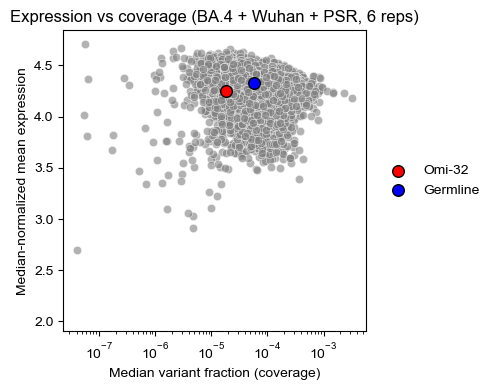

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))

# main scatter
sns.scatterplot(
    data=expr_merged,
    x="median_variant_fraction_global",
    y="expr_mednorm_mean",
    color="gray",
    alpha=0.6,
    ax=ax
)

# highlight Omi-32 and Germline
omi = expr_merged[expr_merged["geno"] == "1111111111111"]
gl  = expr_merged[expr_merged["geno"] == "0000000000000"]

if not omi.empty:
    ax.scatter(
        omi["median_variant_fraction_global"],
        omi["expr_mednorm_mean"],
        color="red",
        s=70,
        label="Omi-32",
        edgecolor="black",
        zorder=5
    )
if not gl.empty:
    ax.scatter(
        gl["median_variant_fraction_global"],
        gl["expr_mednorm_mean"],
        color="blue",
        s=70,
        label="Germline",
        edgecolor="black",
        zorder=5
    )

ax.set_xscale("log")
ax.set_xlabel("Median variant fraction (coverage)")
ax.set_ylabel("Median-normalized mean expression")
ax.set_title("Expression vs coverage (BA.4 + Wuhan + PSR, 6 reps)")

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)

plt.tight_layout()
plt.show()


/var/folders/nr/hfs_n73j0rz58w_x1f9_kzhw0000gp/T/ipykernel_80645/909224111.py:38: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/nr/hfs_n73j0rz58w_x1f9_kzhw0000gp/T/ipykernel_80645/909224111.py:38: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/cole.tharp/miniforge3/envs/epistasis/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/cole.tharp/miniforge3/envs/epistasis/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


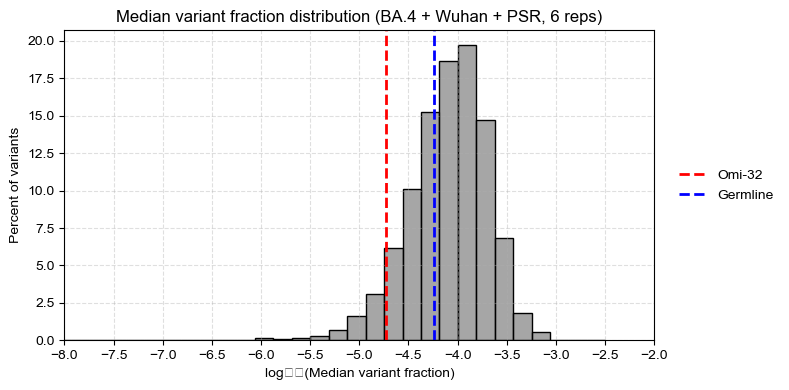

Median log10(variant fraction): -4.057263852932456
Mean log10(variant fraction):   -4.105269200516309


In [ ]:
expr_merged["log10_variant_fraction"] = np.log10(
    np.clip(expr_merged["median_variant_fraction_global"], 1e-10, None)
)

fig, ax = plt.subplots(figsize=(8, 4))  

sns.histplot(
    data=expr_merged,
    x="log10_variant_fraction",
    stat="percent",
    bins=40,
    color="gray",
    alpha=0.7,
    ax=ax
)

# highlight Omi-32 and Germline
omi = expr_merged.loc[expr_merged["geno"] == "1111111111111", "log10_variant_fraction"]
gl  = expr_merged.loc[expr_merged["geno"] == "0000000000000", "log10_variant_fraction"]

if not omi.empty:
    ax.axvline(omi.iloc[0], color="red", linestyle="--", linewidth=2, label="Omi-32")
if not gl.empty:
    ax.axvline(gl.iloc[0], color="blue", linestyle="--", linewidth=2, label="Germline")

ax.set_xlim(-8, -2)
ax.set_xticks(np.arange(-8, -1.5, 0.5))
ax.set_xlabel("log₁₀(Median variant fraction)")
ax.set_ylabel("Percent of variants")
ax.set_title("Median variant fraction distribution (BA.4 + Wuhan + PSR, 6 reps)")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
ax.grid(True, which="major", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# summary stats
print("Median log10(variant fraction):", expr_merged["log10_variant_fraction"].median())
print("Mean log10(variant fraction):  ", expr_merged["log10_variant_fraction"].mean())


42 genotypes have SEM > 0.5


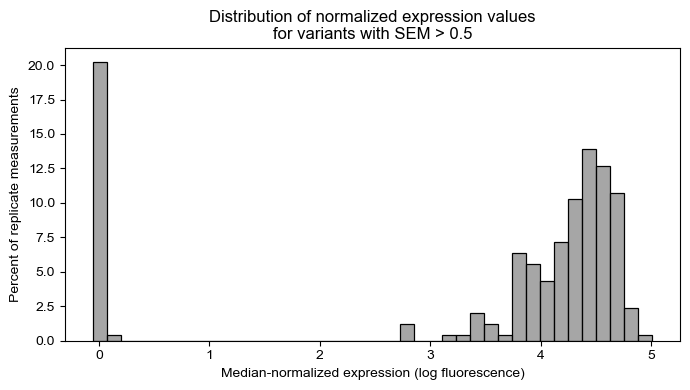

High-SEM expression range: -0.05610454088730421 to 5.006009203406746
Median: 4.252556601335792 Mean: 3.3881323486216615


In [ ]:
#  1) collect replicate columns
rep_cols = [
    "ba4_expr_r1", "ba4_expr_r2",
    "wuhan_expr_r1", "wuhan_expr_r2",
    "psr_expr_r1", "psr_expr_r2"
]

# 2) filter variants with high SEM (> 0.5)
high_sem = expr_merged.loc[expr_merged["expr_mednorm_sem"] > 0.5].copy()
print(f"{len(high_sem)} genotypes have SEM > 0.5")

# 3) gather replicate expression values
vals = high_sem[rep_cols].melt(value_name="expr_value")["expr_value"].dropna()

# 4) plot histogram of all replicate expression values for high-SEM variants
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(vals, bins=40, stat="percent", color="gray", alpha=0.7, ax=ax)

ax.set_xlabel("Median-normalized expression (log fluorescence)")
ax.set_ylabel("Percent of replicate measurements")
ax.set_title("Distribution of normalized expression values\nfor variants with SEM > 0.5")
plt.tight_layout()
plt.show()

print("High-SEM expression range:", vals.min(), "to", vals.max())
print("Median:", vals.median(), "Mean:", vals.mean())


42 genotypes have SEM > 0.5


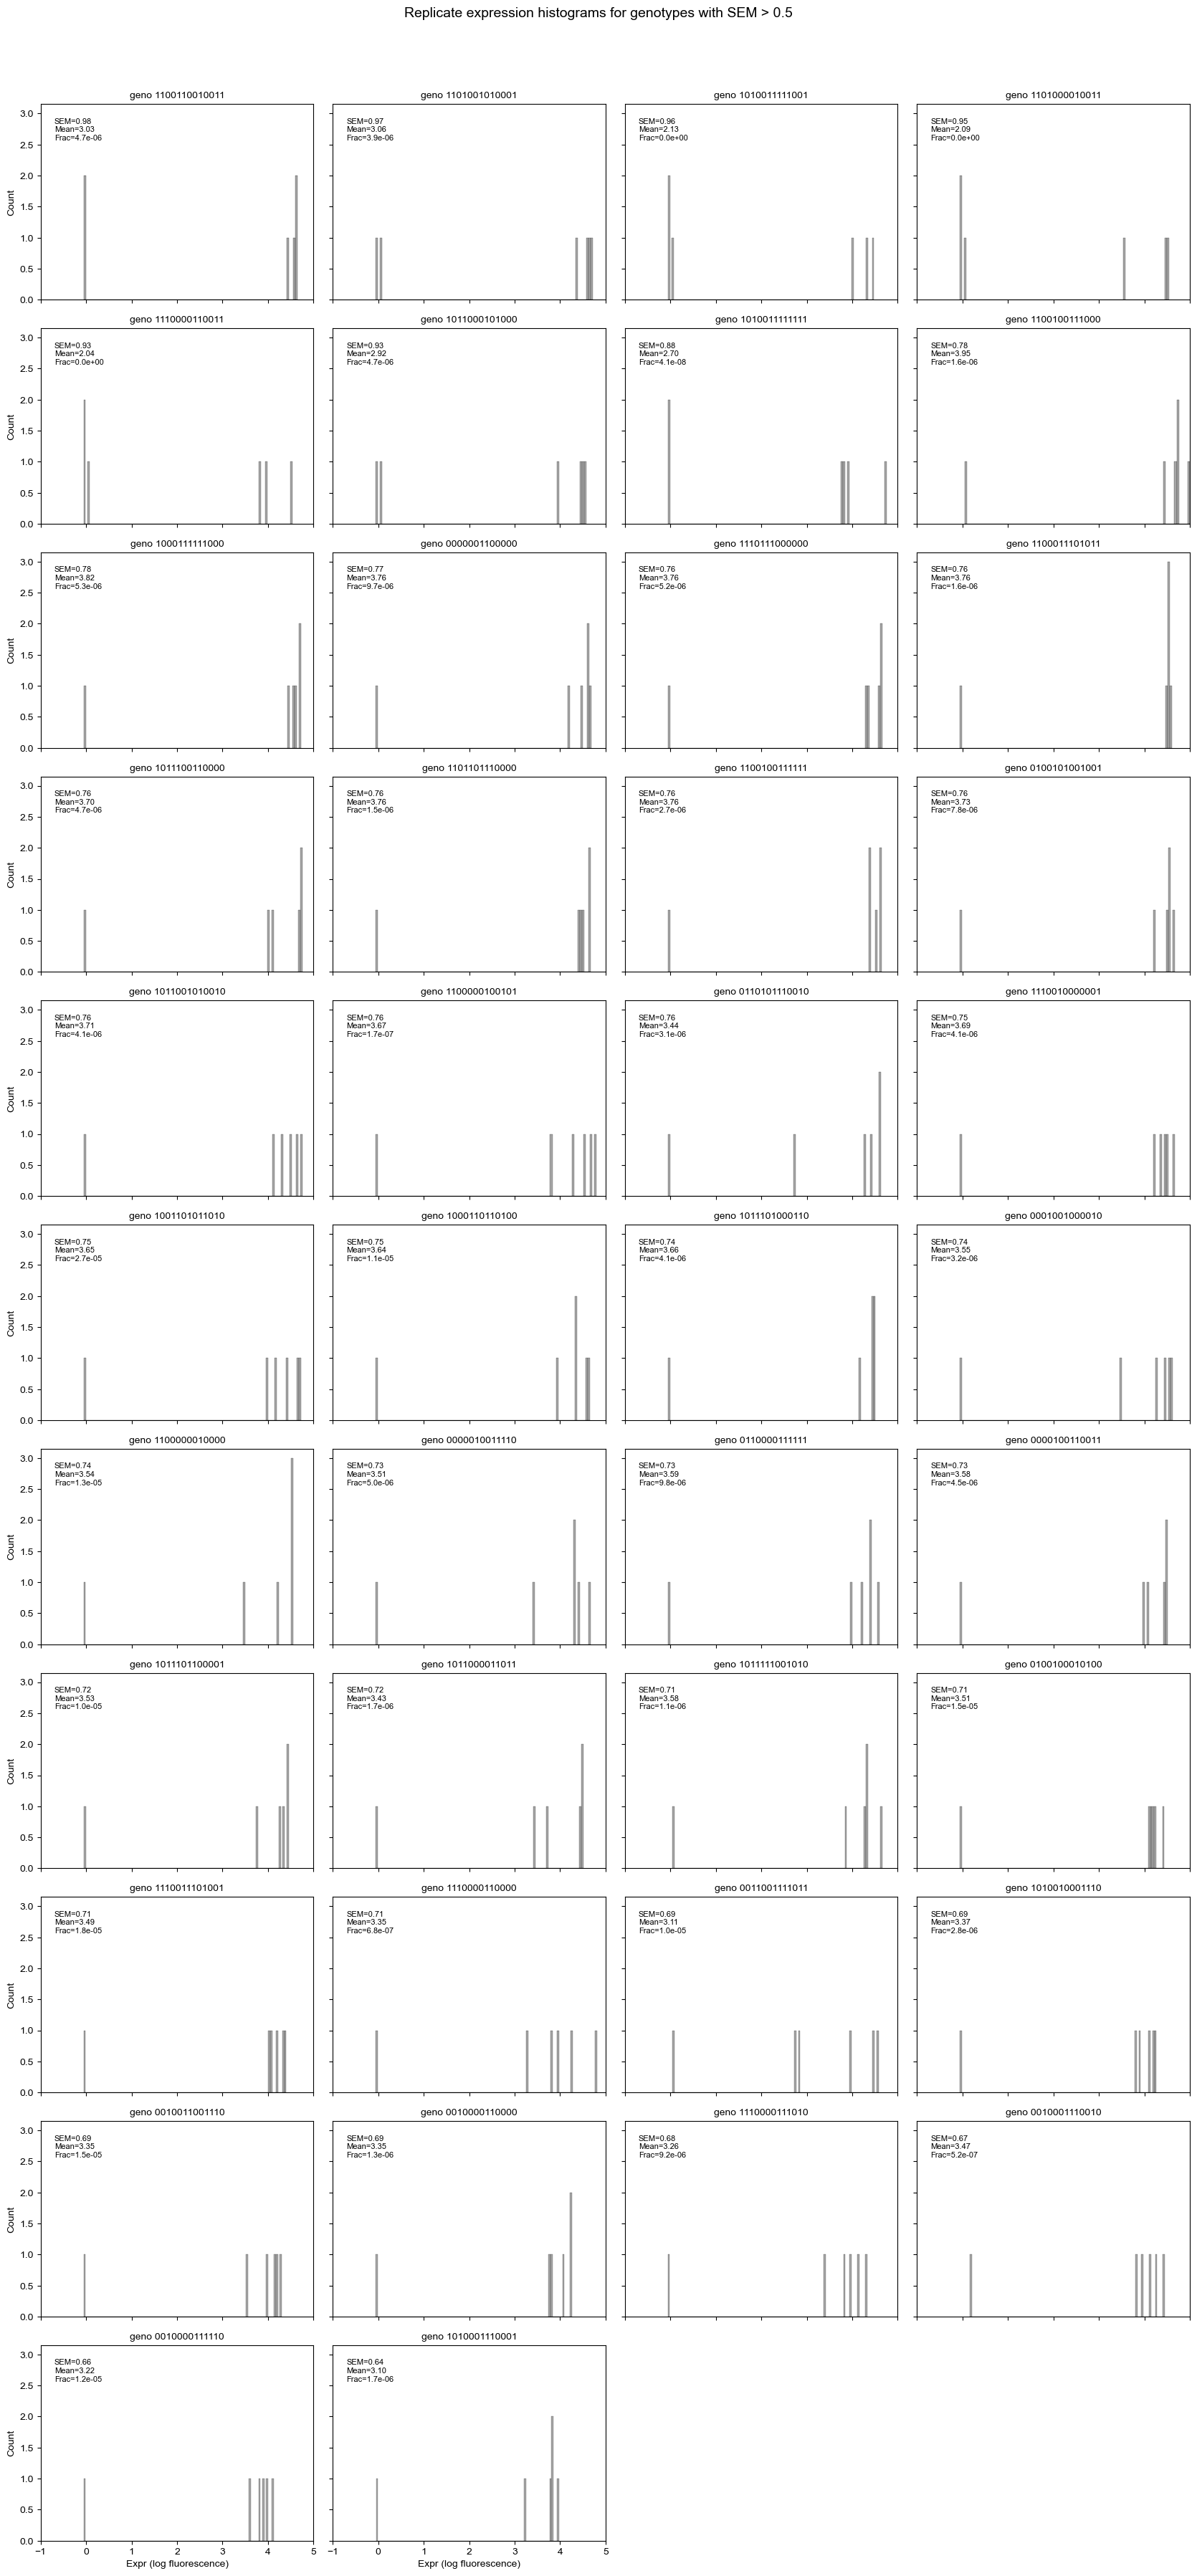

In [ ]:
rep_cols = [
    "ba4_expr_r1", "ba4_expr_r2",
    "wuhan_expr_r1", "wuhan_expr_r2",
    "psr_expr_r1", "psr_expr_r2"
]

# filter high-SEM genotypes
high_sem = expr_merged.loc[expr_merged["expr_mednorm_sem"] > 0.5].copy()
high_sem = high_sem.sort_values("expr_mednorm_sem", ascending=False)
n = len(high_sem)
print(f"{n} genotypes have SEM > 0.5")

cols = 4
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4.2*cols, 3.2*rows), sharex=True, sharey=True)
axes = axes.flatten()

for i, (idx, row) in enumerate(high_sem.iterrows()):
    vals = row[rep_cols].values.astype(float)
    vals = vals[~np.isnan(vals)]

    ax = axes[i]
    sns.histplot(vals, bins=100, stat="count", color="gray", alpha=0.7, ax=ax)
    ax.set_title(f"geno {row['geno']}", fontsize=10)
    ax.set_xlim(-1, 5)
    ax.set_xticks([-1,0,1,2, 3, 4, 5])
    ax.set_xlabel("Expr (log fluorescence)")
    ax.set_ylabel("Count")

    sem_val = row["expr_mednorm_sem"]
    mean_expr = row["expr_mednorm_mean"]
    mean_frac = row["median_variant_fraction_global"]

    ax.text(
        0.05, 0.93,
        f"SEM={sem_val:.2f}\nMean={mean_expr:.2f}\nFrac={mean_frac:.1e}",
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.7, lw=0)
    )

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Replicate expression histograms for genotypes with SEM > 0.5", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
rep_cols = [
    "ba4_expr_r1", "ba4_expr_r2",
    "wuhan_expr_r1", "wuhan_expr_r2",
    "psr_expr_r1", "psr_expr_r2"
]

# find genotypes where any replicate expression < 1
mask_any_below_1 = (expr_merged[rep_cols] < 1).any(axis=1)
num_below = mask_any_below_1.sum()

print(f"Number of genotypes where ANY replicate expression < 1: {num_below}")

genos_below = expr_merged.loc[mask_any_below_1, "geno"]
print("Example genotypes with low expression (<1):")
print(genos_below.head().to_list())


Number of genotypes where ANY replicate expression < 1: 42
Example genotypes with low expression (<1):
['0000001100000', '0000010011110', '0000100110011', '0001001000010', '0010000110000']


In [ ]:
### save filtered table with all replicates for genotypes with SEM ≤ 0.5 since variants with greater SEM than this have low coverage (aren't covered across all datasets)
rep_cols = [
    "ba4_expr_r1", "ba4_expr_r2",
    "wuhan_expr_r1", "wuhan_expr_r2",
    "psr_expr_r1", "psr_expr_r2"
]

cols_to_save = ["geno", "expr_mednorm_mean", "expr_mednorm_sem"] + rep_cols

# filter out high-SEM variants (> 0.5)
filtered = expr_merged.loc[expr_merged["expr_mednorm_sem"] <= 0.5, cols_to_save].copy()

# save to CSV
output_path = "filtered_expression_replicates.csv"
filtered.to_csv(output_path, index=False)

print(f"Saved {len(filtered)} genotypes (SEM ≤ 0.5) to '{output_path}'")


Saved 8150 genotypes (SEM ≤ 0.5) to 'filtered_expression_replicates.csv'


# Quality-control of affinity datasets (see methods for complete description of rationale)

In [50]:
### calculate log ratio of inferred maximum binding signal (traditionally referred to as Bmax, here it's referred to as 'A') to expression and calculate robust z-scores from median log(A/expression)ratios for all datasets


# 1) Load filtered averaged-expression CSV

expr_final = pd.read_csv("filtered_expression_replicates.csv")

expr_final["geno"] = expr_final["geno"].astype(str).str.zfill(13)
expr_final = expr_final.rename(columns={"expr_mednorm_mean": "avg_expr"})

# 2) Helper to standardize geno & merge avg_expr

def ensure_geno_str(df, zpad=13):
    df = df.copy()
    df["geno"] = df["geno"].astype(str).str.zfill(zpad)
    return df

def add_avg_expr(df, expr_df):
    df = ensure_geno_str(df)
    return df.merge(expr_df[["geno", "avg_expr"]], on="geno", how="left")


# 3) calculate log10(A/expression) and z-scores from median and MAD of log10(A/expression) across all variants in the dataset

def add_log_ratio_and_stats(df, col_A="A", col_avg_expr_log="avg_expr"):
    out = df.copy()
    mask = out[col_A].gt(0) & out[col_avg_expr_log].notna()
    out["log_A_over_expr"] = np.where(
        mask,
        np.log10(out[col_A]) - out[col_avg_expr_log],
        np.nan
    )
    series = out["log_A_over_expr"].dropna()
    if len(series) > 0:
        median_val = series.median()
        print(F" median val: {median_val}")
        mad_val = (series - median_val).abs().median()
        print(F"mad val: {mad_val}")
    else:
        median_val, mad_val = np.nan, np.nan
    out["median_log_A_over_expr"] = median_val
    out["mad_log_A_over_expr"] = mad_val
    if mad_val and not np.isnan(mad_val) and mad_val > 0:
        out["z_score_log_A_over_expr"] = (out["log_A_over_expr"] - median_val) / mad_val
    else:
        out["z_score_log_A_over_expr"] = np.nan
    return out

# 4) Apply to all datasets (BA.4, BA.1, Wuhan, PSR)

datasets = {
    "ba4_1": ba4_1, "ba4_2": ba4_2,
    "ba1_1": ba1_1, "ba1_2": ba1_2,
    "wuhan_1": wuhan_1, "wuhan_2": wuhan_2,
    "psr_1": psr_1, "psr_2": psr_2,
}

for name, df in datasets.items():
    df = add_avg_expr(df, expr_final)
    df = add_log_ratio_and_stats(df, col_A="A", col_avg_expr_log="avg_expr")
    datasets[name] = df

ba4_1, ba4_2 = datasets["ba4_1"], datasets["ba4_2"]
ba1_1, ba1_2 = datasets["ba1_1"], datasets["ba1_2"]
wuhan_1, wuhan_2 = datasets["wuhan_1"], datasets["wuhan_2"]
psr_1, psr_2 = datasets["psr_1"], datasets["psr_2"]

 median val: -0.11169010611163976
mad val: 0.19906675109727878
 median val: -0.11825322440980557
mad val: 0.201881266204345
 median val: -0.48088931064089824
mad val: 0.1332242331668576
 median val: -0.09942151481446793
mad val: 0.14290287944420044
 median val: -0.04609496281964187
mad val: 0.1651759241070705
 median val: 0.053106862942232436
mad val: 0.13012822611812425
 median val: -0.9516918164187032
mad val: 0.21246741423182725
 median val: -0.9902192603890678
mad val: 0.2206454917869083


/var/folders/nr/hfs_n73j0rz58w_x1f9_kzhw0000gp/T/ipykernel_80645/3576346037.py:67: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return st.spearmanr(x, y, nan_policy="omit")[0]



=== Best Z per pair (Pearson) ===
    pair    z    r_full  rho_full  pct_below7p5   pct_left     n
0  Wuhan  1.8  0.702588  0.755306     14.894170  94.006348  7701
1    BA4  1.9  0.834455  0.834779     24.827674  95.629883  7834
2    BA1  3.4  0.654442  0.693896      4.749833  91.491699  7495

=== Best Z per pair (Spearman) ===
    pair    z    r_full  rho_full  pct_below7p5   pct_left     n
0  Wuhan  1.8  0.702588  0.755306     14.894170  94.006348  7701
1    BA4  1.9  0.834455  0.834779     24.827674  95.629883  7834
2    BA1  3.4  0.654442  0.693896      4.749833  91.491699  7495


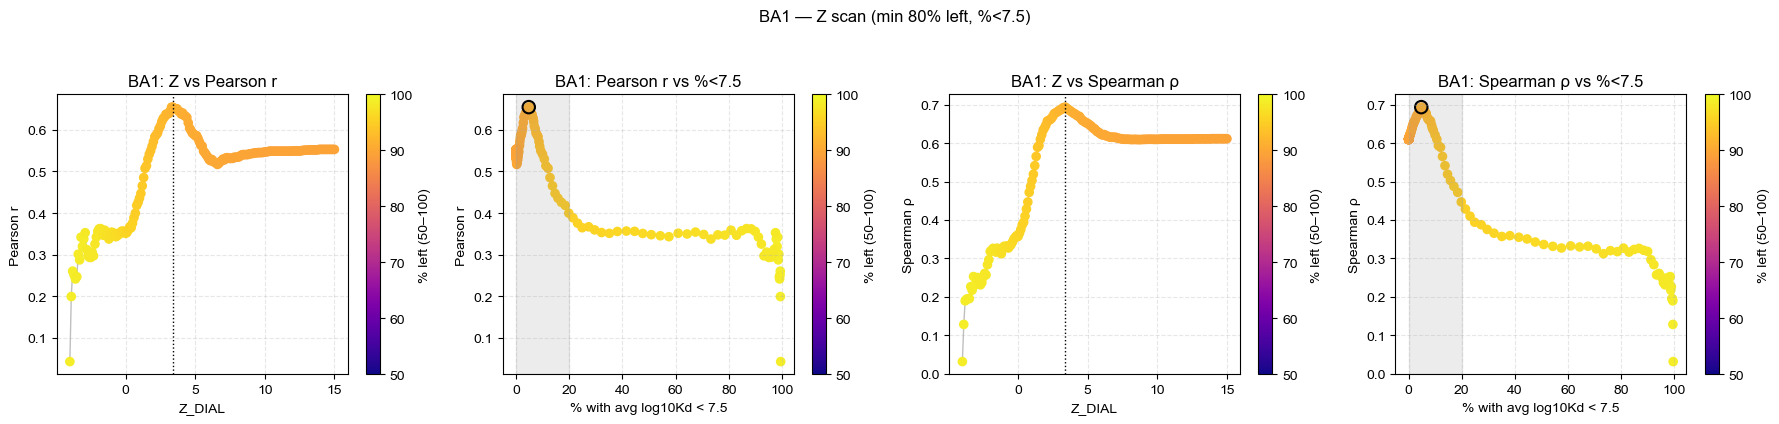

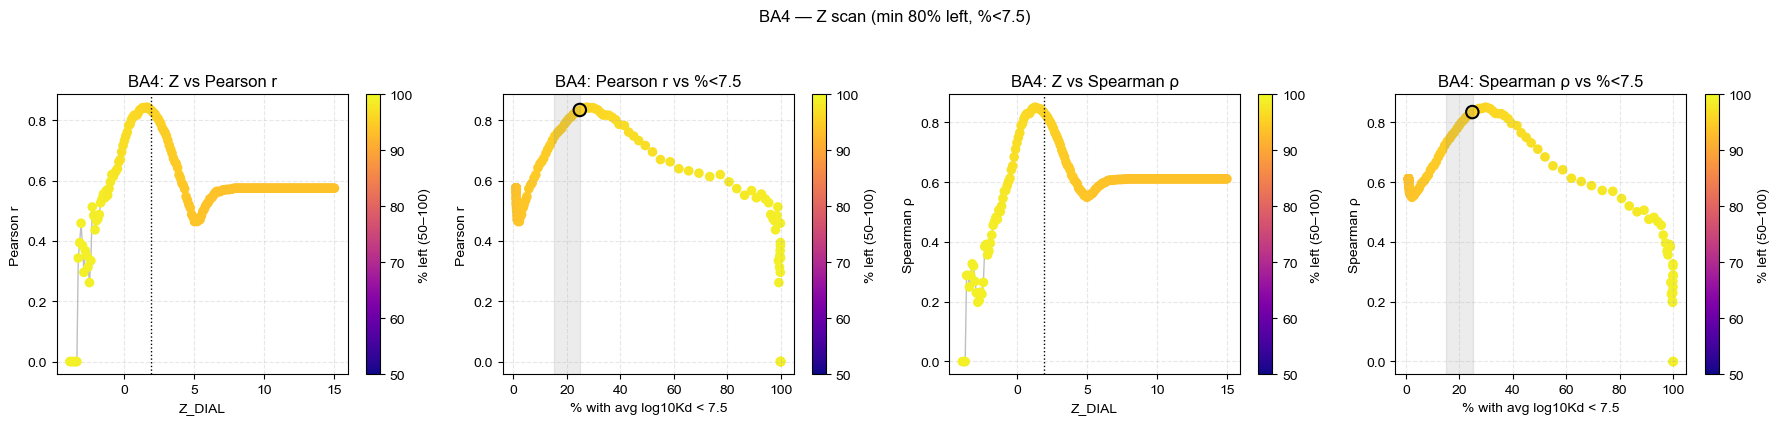

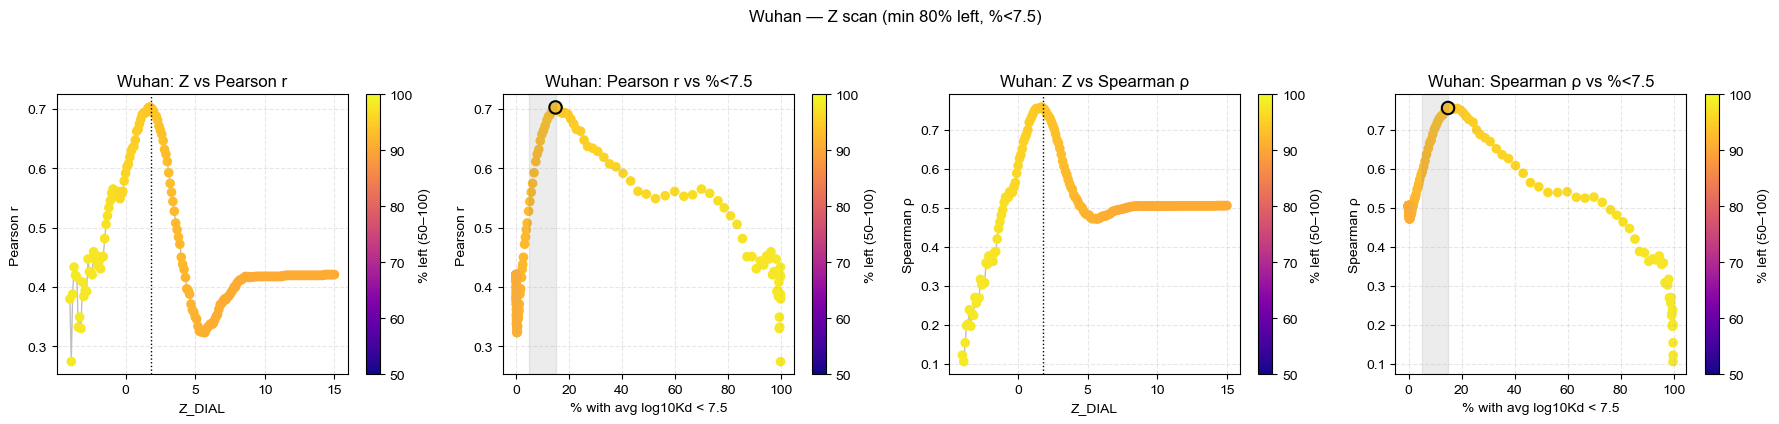

In [57]:
### run a Z scan to find optimal Z thresholds for each pair based on Pearson r and Spearman rho, while ensuring that we don't exclude too many variants (e.g. by enforcing a minimum percentage of variants left after filtering based off of flow cytometry data)

# 0) INPUT DATASETS

non_um_pairs = {
    "Wuhan": (wuhan_1, wuhan_2),
    "BA4":   (ba4_1,   ba4_2),
    "BA1":   (ba1_1,   ba1_2),
}


# 1) CONFIG

TOTAL_VARIANTS    = 8192
MIN_PCT_LEFT      = 80.0
DETECTION_LOG10KD = 7.0
DELTA_PIN_THRESH = 100

Z_MIN, Z_MAX, Z_STEP = -4.0, 15, 0.1

BOUNDS_BY_PAIR = {
    "Wuhan": (5, 15),
    "BA4":   (15, 25),
    "BA1":   (0, 20),
}

REQUIRED_COLS = [
    "A",
    "log10Kd",
    "geno",
    "sigma",
    "r2",
    "median_variant_fraction",
    "avg_expr",
]


# 2) helper functions for preprocessing, merging, and QC

def _coerce_numeric(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

def _normalize_geno(df):
    df["geno"] = df["geno"].astype(str)
    return df

def pearson_r(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if len(x) < 2:
        return np.nan
    if np.allclose(x, x.mean()) or np.allclose(y, y.mean()):
        return np.nan
    return st.pearsonr(x, y)[0]

def spearman_rho(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if len(x) < 2:
        return np.nan
    return st.spearmanr(x, y, nan_policy="omit")[0]

def _add_log_ratio_stats(df, z_dial):
    out = df.copy()
    mask = (out["A"] > 0) & out["avg_expr"].notna()
    out["log_A_over_expr"] = np.where(
        mask,
        np.log10(out["A"]) - out["avg_expr"],
        np.nan,
    )
    s = out["log_A_over_expr"].dropna()
    if len(s) > 0:
        med = s.median()
        mad = (s - med).abs().median()
    else:
        med, mad = np.nan, np.nan
    out["lower_threshold_log_ratio"] = (
        med - z_dial * mad if (pd.notna(med) and pd.notna(mad)) else med
    )
    return out

def preprocess_param(df, z_dial, sigma_thresh=1.0, frac_thresh=1e-6, r2_thresh=0.8):
    df = df.copy()
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    _coerce_numeric(df, ["A", "log10Kd", "sigma", "r2", "median_variant_fraction", "avg_expr"])
    df = df.dropna(subset=REQUIRED_COLS).copy()
    df = _normalize_geno(df)

    df = _add_log_ratio_stats(df, z_dial)
    below = df["log_A_over_expr"] < df["lower_threshold_log_ratio"]

    to_pin  = below & (df["median_variant_fraction"] >= frac_thresh)
    to_drop = below & (df["median_variant_fraction"] <  frac_thresh)

    # pin if below threshold but sufficient coverage
    df.loc[to_pin, "log10Kd"] = DETECTION_LOG10KD

    # QC
    keep_qc = (~below) & (df["r2"] >= r2_thresh) & (df["sigma"] < sigma_thresh)

    keep_mask = to_pin | keep_qc
    return df.loc[keep_mask, ["geno", "log10Kd"]].dropna()

def postmerge_housekeeping(merged, inconsistency_thresh=DELTA_PIN_THRESH):
    merged = merged.copy()
    merged["log10Kd_rep1"] = np.maximum(merged["log10Kd_rep1"], DETECTION_LOG10KD)
    merged["log10Kd_rep2"] = np.maximum(merged["log10Kd_rep2"], DETECTION_LOG10KD)
    rep1_pin = np.isclose(merged["log10Kd_rep1"], DETECTION_LOG10KD)
    rep2_pin = np.isclose(merged["log10Kd_rep2"], DETECTION_LOG10KD)
    xor_pinned = rep1_pin ^ rep2_pin
    too_far = (merged["log10Kd_rep1"] - merged["log10Kd_rep2"]).abs() > inconsistency_thresh
    return merged.loc[~(xor_pinned & too_far)].copy()

# 3) Z scan to find optimal Z thresholds for each pair based on Pearson r and Spearman rho, while ensuring sufficient coverage and %<7.5

def run_z_scan(non_um_pairs, bounds_by_pair,
               total_variants=TOTAL_VARIANTS,
               z_min=Z_MIN, z_max=Z_MAX, z_step=Z_STEP):
    z_grid = np.round(np.arange(z_min, z_max + 1e-9, z_step), 3)
    results = []
    best_by_pair_pearson = {}
    best_by_pair_spearman = {}

    for pair_label, (df1_raw, df2_raw) in non_um_pairs.items():
        low, high = bounds_by_pair[pair_label]
        best_p = None
        best_s = None

        for z in z_grid:
            df1 = preprocess_param(df1_raw, z)
            df2 = preprocess_param(df2_raw, z)

            merged = df1.merge(df2, on="geno", suffixes=("_rep1", "_rep2")).dropna()
            if merged.empty:
                continue

            merged = postmerge_housekeeping(merged, inconsistency_thresh=DELTA_PIN_THRESH)
            if merged.empty:
                continue

            x = merged["log10Kd_rep1"].to_numpy()
            y = merged["log10Kd_rep2"].to_numpy()

            r_full   = pearson_r(x, y)
            rho_full = spearman_rho(x, y)

            pct_left = 100.0 * len(merged) / float(total_variants)

            # measure below 7.5
            avg_kd = (x + y) / 2.0
            pct_below7p5 = (avg_kd < 7.5).mean() * 100.0

            row = dict(
                pair=pair_label,
                z=z,
                r_full=r_full,
                rho_full=rho_full,
                pct_below7p5=pct_below7p5,
                pct_left=pct_left,
                n=len(merged),
            )
            results.append(row)

            valid = (low <= pct_below7p5 <= high) and (pct_left >= MIN_PCT_LEFT)

            if valid and np.isfinite(r_full):
                if (best_p is None) or (r_full > best_p["r_full"]) or \
                   (np.isclose(r_full, best_p["r_full"]) and pct_left > best_p["pct_left"]):
                    best_p = row

            if valid and np.isfinite(rho_full):
                if (best_s is None) or (rho_full > best_s["rho_full"]) or \
                   (np.isclose(rho_full, best_s["rho_full"]) and pct_left > best_s["pct_left"]):
                    best_s = row

        best_by_pair_pearson[pair_label]  = best_p
        best_by_pair_spearman[pair_label] = best_s

    res_df = pd.DataFrame(results)

    best_p_df = pd.DataFrame(
        [best_by_pair_pearson[k] for k in best_by_pair_pearson if best_by_pair_pearson[k] is not None]
    )
    best_s_df = pd.DataFrame(
        [best_by_pair_spearman[k] for k in best_by_pair_spearman if best_by_pair_spearman[k] is not None]
    )

    return res_df, best_p_df, best_s_df, best_by_pair_pearson, best_by_pair_spearman

# 4) plot Z scan results for each pair, highlighting best Z thresholds and valid regions based on %<7.5 and % left

def plot_z_scan(res_df, best_by_pair_p, best_by_pair_s, bounds_by_pair):
    pairs = sorted(res_df["pair"].unique())
    for pair in pairs:
        sub = res_df[res_df["pair"] == pair].sort_values("z").copy()
        low, high = bounds_by_pair[pair]
        best_p = best_by_pair_p.get(pair)
        best_s = best_by_pair_s.get(pair)

        fig, axes = plt.subplots(1, 4, figsize=(18, 4), squeeze=False)
        axes = axes[0]

        # 1) Z vs Pearson
        ax1 = axes[0]
        ax1.plot(sub["z"], sub["r_full"], color="gray", lw=1, alpha=0.5, zorder=1)
        sc1 = ax1.scatter(sub["z"], sub["r_full"],
                          c=sub["pct_left"],
                          cmap="plasma",
                          vmin=50, vmax=100,
                          s=35, zorder=2)
        if best_p:
            ax1.axvline(best_p["z"], color="k", linestyle=":", lw=1)
        cb1 = plt.colorbar(sc1, ax=ax1); cb1.set_label("% left (50–100)")
        ax1.set_title(f"{pair}: Z vs Pearson r")
        ax1.set_xlabel("Z_DIAL"); ax1.set_ylabel("Pearson r")
        ax1.grid(True, linestyle="--", alpha=0.3)

        # 2) Pearson r vs %<7.5
        ax2 = axes[1]
        sc2 = ax2.scatter(sub["pct_below7p5"], sub["r_full"],
                          c=sub["pct_left"],
                          cmap="plasma",
                          vmin=50, vmax=100,
                          s=35)
        ax2.axvspan(low, high, color="gray", alpha=0.15)
        if best_p:
            ax2.scatter(best_p["pct_below7p5"], best_p["r_full"],
                        s=80, facecolors="none", edgecolors="k", linewidths=1.5)
        cb2 = plt.colorbar(sc2, ax=ax2); cb2.set_label("% left (50–100)")
        ax2.set_title(f"{pair}: Pearson r vs %<7.5")
        ax2.set_xlabel("% with avg log10Kd < 7.5"); ax2.set_ylabel("Pearson r")
        ax2.grid(True, linestyle="--", alpha=0.3)

        # 3) Z vs Spearman
        ax3 = axes[2]
        ax3.plot(sub["z"], sub["rho_full"], color="gray", lw=1, alpha=0.5, zorder=1)
        sc3 = ax3.scatter(sub["z"], sub["rho_full"],
                          c=sub["pct_left"],
                          cmap="plasma",
                          vmin=50, vmax=100,
                          s=35, zorder=2)
        if best_s:
            ax3.axvline(best_s["z"], color="k", linestyle=":", lw=1)
        cb3 = plt.colorbar(sc3, ax=ax3); cb3.set_label("% left (50–100)")
        ax3.set_title(f"{pair}: Z vs Spearman ρ")
        ax3.set_xlabel("Z_DIAL"); ax3.set_ylabel("Spearman ρ")
        ax3.grid(True, linestyle="--", alpha=0.3)

        # 4) Spearman ρ vs %<7.5
        ax4 = axes[3]
        sc4 = ax4.scatter(sub["pct_below7p5"], sub["rho_full"],
                          c=sub["pct_left"],
                          cmap="plasma",
                          vmin=50, vmax=100,
                          s=35)
        ax4.axvspan(low, high, color="gray", alpha=0.15)
        if best_s:
            ax4.scatter(best_s["pct_below7p5"], best_s["rho_full"],
                        s=80, facecolors="none", edgecolors="k", linewidths=1.5)
        cb4 = plt.colorbar(sc4, ax=ax4); cb4.set_label("% left (50–100)")
        ax4.set_title(f"{pair}: Spearman ρ vs %<7.5")
        ax4.set_xlabel("% with avg log10Kd < 7.5"); ax4.set_ylabel("Spearman ρ")
        ax4.grid(True, linestyle="--", alpha=0.3)

        fig.suptitle(f"{pair} — Z scan (min {MIN_PCT_LEFT:.0f}% left, %<7.5)", y=1.05)
        plt.tight_layout()
        plt.show()


# run Z scan and plot results
z_res_df, z_best_p_df, z_best_s_df, z_best_by_pair_p, z_best_by_pair_s = run_z_scan(
    non_um_pairs,
    BOUNDS_BY_PAIR,
)
print("\n=== Best Z per pair (Pearson) ===")
print(z_best_p_df)
print("\n=== Best Z per pair (Spearman) ===")
print(z_best_s_df)

plot_z_scan(z_res_df, z_best_by_pair_p, z_best_by_pair_s, BOUNDS_BY_PAIR)



=== Wuhan ===
  Wuhan — (1) raw / uncleaned: 0.18% below 7.5; 99.67% of 8192 retained.
    Canvas size: 1 × 1 inches
    Total figure size: 1.80 × 1.70 inches
    At 2000 DPI: 3600 × 3400 pixels


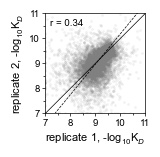

  Wuhan — (2) pinned only (z=1.8, freq=1e-07): 14.84% below 7.5; 99.34% of 8192 retained.
    Canvas size: 1 × 1 inches
    Total figure size: 1.80 × 1.70 inches
    At 2000 DPI: 3600 × 3400 pixels


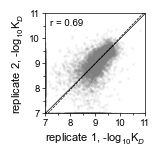

  Wuhan — (3) pinned + QC (z=1.8, σ<1, r2>=0.8, freq>=1e-07): 14.97% below 7.5; 94.15% of 8192 retained.
    Canvas size: 1 × 1 inches
    Total figure size: 1.80 × 1.70 inches
    At 2000 DPI: 3600 × 3400 pixels


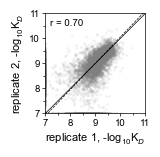

  Wuhan — (4) pinned + QC + Δdrop (Δ>1.0): 17.14% below 7.5; 82.28% of 8192 retained.
    Canvas size: 1 × 1 inches
    Total figure size: 1.80 × 1.70 inches
    At 2000 DPI: 3600 × 3400 pixels


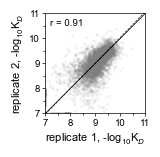


=== BA4 ===
  BA4 — (1) raw / uncleaned: 1.16% below 7.5; 99.82% of 8192 retained.
    Canvas size: 1 × 1 inches
    Total figure size: 1.80 × 1.70 inches
    At 2000 DPI: 3600 × 3400 pixels


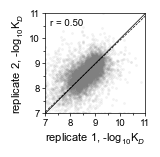

  BA4 — (2) pinned only (z=1.9, freq=1e-07): 24.72% below 7.5; 99.41% of 8192 retained.
    Canvas size: 1 × 1 inches
    Total figure size: 1.80 × 1.70 inches
    At 2000 DPI: 3600 × 3400 pixels


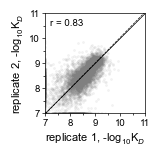

  BA4 — (3) pinned + QC (z=1.9, σ<1, r2>=0.8, freq>=1e-07): 24.89% below 7.5; 95.73% of 8192 retained.
    Canvas size: 1 × 1 inches
    Total figure size: 1.80 × 1.70 inches
    At 2000 DPI: 3600 × 3400 pixels


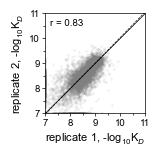

  BA4 — (4) pinned + QC + Δdrop (Δ>1.0): 26.32% below 7.5; 90.53% of 8192 retained.
    Canvas size: 1 × 1 inches
    Total figure size: 1.80 × 1.70 inches
    At 2000 DPI: 3600 × 3400 pixels


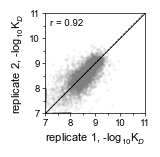


=== BA1 ===
  BA1 — (1) raw / uncleaned: 0.07% below 7.5; 99.77% of 8192 retained.
    Canvas size: 1 × 1 inches
    Total figure size: 1.80 × 1.70 inches
    At 2000 DPI: 3600 × 3400 pixels


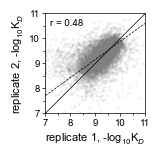

  BA1 — (2) pinned only (z=3.4, freq=1e-07): 4.56% below 7.5; 99.34% of 8192 retained.
    Canvas size: 1 × 1 inches
    Total figure size: 1.80 × 1.70 inches
    At 2000 DPI: 3600 × 3400 pixels


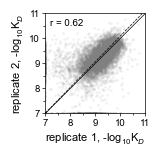

  BA1 — (3) pinned + QC (z=3.4, σ<1, r2>=0.8, freq>=1e-07): 4.76% below 7.5; 91.55% of 8192 retained.
    Canvas size: 1 × 1 inches
    Total figure size: 1.80 × 1.70 inches
    At 2000 DPI: 3600 × 3400 pixels


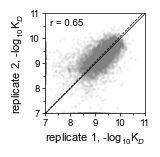

  BA1 — (4) pinned + QC + Δdrop (Δ>1.0): 5.07% below 7.5; 85.90% of 8192 retained.
    Canvas size: 1 × 1 inches
    Total figure size: 1.80 × 1.70 inches
    At 2000 DPI: 3600 × 3400 pixels


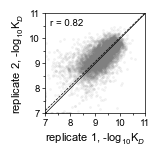

[write] wuhan_affinity_cleaned.csv  (rows=6740)
[write] ba4_affinity_cleaned.csv  (rows=7416)
[write] ba1_affinity_cleaned.csv  (rows=7037)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import scipy.odr as odr
from matplotlib.gridspec import GridSpec

### use optimal Z thresholds and other QC criteria to build final cleaned datasets for each pair and evaluate final Pearson r and Spearman rho
## see methods for rationale

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'

# configuration — per-dataset thresholds from Z scan results, total variants, detection limit, and required columns for preprocessing

DATASETS = {
    "Wuhan": (wuhan_1, wuhan_2),
    "BA4":   (ba4_1,   ba4_2),
    "BA1":   (ba1_1,   ba1_2),
}

PARAMS_PER_PAIR = {
    "Wuhan": dict(z=1.8, sigma=1, freq=1e-7, r2=0.80, delta=1.0),
    "BA4":   dict(z=1.9, sigma=1, freq=1e-7, r2=0.80, delta=1.0),
    "BA1":   dict(z=3.4, sigma=1, freq=1e-7, r2=0.80, delta=1.0),
}

TOTAL_VARIANTS    = 8192
DETECTION_LOG10KD = 7.0
ZPAD              = 13
EXPR_CSV          = "filtered_expression_replicates.csv"

REQUIRED_COLS = [
    "A", "log10Kd", "geno", "sigma", "r2",
    "median_variant_fraction", "avg_expr",
]

# helper functions for preprocessing, merging, and QC

def _zfill_geno(df, col="geno", zpad=ZPAD):
    df[col] = df[col].astype(str).str.zfill(zpad)
    return df

def _coerce_numeric(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def _normalize_geno(df):
    df["geno"] = df["geno"].astype(str)
    return df

def _add_log_ratio_stats(df, z_dial):
    out = df.copy()
    mask = (out["A"] > 0) & out["avg_expr"].notna()
    out["log_A_over_expr"] = np.where(
        mask, np.log10(out["A"]) - out["avg_expr"], np.nan
    )
    s = out["log_A_over_expr"].dropna()
    if len(s) > 0:
        med = s.median()
        mad = (s - med).abs().median()
    else:
        med, mad = np.nan, np.nan
    out["median_log_A_over_expr"]    = med
    out["mad_log_A_over_expr"]       = mad
    out["lower_threshold_log_ratio"] = (
        med - z_dial * mad if (pd.notna(med) and pd.notna(mad)) else med
    )
    if pd.notna(mad) and mad > 0:
        out["z_score_log_A_over_expr"] = (out["log_A_over_expr"] - med) / mad
    else:
        out["z_score_log_A_over_expr"] = np.nan
    return out

def pearson_r_unbiased(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if len(x) < 2:
        return np.nan
    if np.allclose(x, x.mean()) or np.allclose(y, y.mean()):
        return np.nan
    return st.pearsonr(x, y)[0]

def spearman_rho(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if len(x) < 2:
        return np.nan
    return st.spearmanr(x, y, nan_policy="omit")[0]

def build_raw(df1, df2):
    df1 = df1.copy(); df2 = df2.copy()
    _normalize_geno(df1); _normalize_geno(df2)
    _coerce_numeric(df1, ["log10Kd"]); _coerce_numeric(df2, ["log10Kd"])
    merged = df1[["geno", "log10Kd"]].merge(
        df2[["geno", "log10Kd"]],
        on="geno", how="inner", suffixes=("_rep1", "_rep2")
    ).dropna()
    return merged

def pin_only(df, z_dial, freq_thresh):
    df = df.copy()
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns: {missing}")
    _coerce_numeric(df, ["A", "log10Kd", "sigma", "r2", "median_variant_fraction", "avg_expr"])
    df = df.dropna(subset=REQUIRED_COLS).copy()
    _normalize_geno(df)
    df = _add_log_ratio_stats(df, z_dial)
    below  = df["log_A_over_expr"] < df["lower_threshold_log_ratio"]
    to_pin = below & (df["median_variant_fraction"] >= freq_thresh)
    df.loc[to_pin, "log10Kd"] = DETECTION_LOG10KD
    return df[["geno", "log10Kd"]].copy()

def build_pinned_only(df1_raw, df2_raw, z, freq):
    p1 = pin_only(df1_raw, z, freq)
    p2 = pin_only(df2_raw, z, freq)
    merged = p1.merge(p2, on="geno", how="inner", suffixes=("_rep1", "_rep2")).dropna()
    return merged

def preprocess_replicate(df, z_dial, sigma_thresh, freq_thresh, r2_thresh):
    df = df.copy()
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")
    df = _zfill_geno(df)
    df = _coerce_numeric(df, ["A", "log10Kd", "sigma", "r2", "median_variant_fraction", "avg_expr"])
    df = df.dropna(subset=REQUIRED_COLS).copy()
    df = _add_log_ratio_stats(df, z_dial)
    below   = df["log_A_over_expr"] < df["lower_threshold_log_ratio"]
    to_pin  = below & (df["median_variant_fraction"] >= freq_thresh)
    to_drop = below & (df["median_variant_fraction"] <  freq_thresh)
    df.loc[to_pin, "log10Kd"] = DETECTION_LOG10KD
    keep_qc   = (~below) & (df["r2"] >= r2_thresh) & (df["sigma"] < sigma_thresh)
    keep_mask = to_pin | keep_qc
    return df.loc[keep_mask, [
        "geno", "log10Kd", "r2", "sigma", "median_variant_fraction",
        "z_score_log_A_over_expr"
    ]].copy()

# alias used by plotting pipeline
def preprocess_param(df, z_dial, sigma_thresh, freq_thresh, r2_thresh):
    return preprocess_replicate(df, z_dial, sigma_thresh, freq_thresh, r2_thresh)

def build_full_nodelta(df1_raw, df2_raw, z, sigma, freq, r2_cut):
    c1 = preprocess_param(df1_raw, z, sigma, freq, r2_cut)
    c2 = preprocess_param(df2_raw, z, sigma, freq, r2_cut)
    merged = c1.merge(c2, on="geno", how="inner", suffixes=("_rep1", "_rep2")).dropna()
    return merged

def postmerge_housekeeping(merged, delta_thresh, detection=DETECTION_LOG10KD):
    merged = merged.copy()
    merged["log10Kd_rep1"] = np.maximum(merged["log10Kd_rep1"], detection)
    merged["log10Kd_rep2"] = np.maximum(merged["log10Kd_rep2"], detection)
    rep1_pin = np.isclose(merged["log10Kd_rep1"], detection)
    rep2_pin = np.isclose(merged["log10Kd_rep2"], detection)
    xor      = rep1_pin ^ rep2_pin
    too_far  = (merged["log10Kd_rep1"] - merged["log10Kd_rep2"]).abs() > delta_thresh
    merged   = merged.loc[~(xor & too_far)].copy()
    return merged

def build_full_with_delta(df1_raw, df2_raw, z, sigma, freq, r2_cut, delta_thresh):
    merged = build_full_nodelta(df1_raw, df2_raw, z, sigma, freq, r2_cut)
    if merged.empty:
        return merged
    return postmerge_housekeeping(merged, delta_thresh)

# plotting with stats

def plot_corr(df_merged, title, total_variants=TOTAL_VARIANTS, save_name=None):
    if df_merged.empty:
        print(f"[WARN] {title}: empty after filtering")
        return
    x = df_merged["log10Kd_rep1"].to_numpy()
    y = df_merged["log10Kd_rep2"].to_numpy()

    r   = pearson_r_unbiased(x, y)
    rho = spearman_rho(x, y)
    n   = len(df_merged)
    pct_remaining = 100.0 * n / total_variants
    avg_vals      = (x + y) / 2.0
    pct_below_7p5 = 100.0 * np.mean(avg_vals < 7.5)

    print(f"  {title}: {pct_below_7p5:.2f}% below 7.5; {pct_remaining:.2f}% of 8192 retained.")

    CANVAS_WIDTH  = 1
    CANVAS_HEIGHT = 1
    LEFT_MARGIN   = 0.6
    RIGHT_MARGIN  = 0.2
    TOP_MARGIN    = 0.2
    BOTTOM_MARGIN = 0.5

    fig_width  = LEFT_MARGIN + CANVAS_WIDTH + RIGHT_MARGIN
    fig_height = TOP_MARGIN + CANVAS_HEIGHT + BOTTOM_MARGIN

    fig = plt.figure(figsize=(fig_width, fig_height))
    gs  = GridSpec(1, 1, figure=fig,
                   left=LEFT_MARGIN/fig_width,
                   right=(LEFT_MARGIN + CANVAS_WIDTH)/fig_width,
                   top=1 - TOP_MARGIN/fig_height,
                   bottom=BOTTOM_MARGIN/fig_height)
    ax = fig.add_subplot(gs[0])

    sns.scatterplot(x=x, y=y, s=3, ax=ax, alpha=0.1, edgecolor=None, color='gray')
    ax.plot([7, 11], [7, 11], 'k-', lw=0.5)

    # correlation line orthogonal least-squares regression via scipy.odr
    x0 = np.asarray(x, float); y0 = np.asarray(y, float)
    m  = np.isfinite(x0) & np.isfinite(y0)
    x0, y0  = x0[m], y0[m]
    model   = odr.Model(lambda B, x: B[0] * x + B[1])
    odr_obj = odr.ODR(odr.RealData(x0, y0), model, beta0=[1.0, 0.0])
    out     = odr_obj.run()
    slope, intercept = out.beta
    x_line = np.array([7, 11])
    ax.plot(x_line, slope * x_line + intercept, 'k--', lw=0.5)

    ax.set_xlim(7, 11); ax.set_ylim(7, 11)
    ax.set_xticks([7, 8, 9, 10, 11]); ax.set_yticks([7, 8, 9, 10, 11])
    ax.set_xticks([7.5, 8.5, 9.5, 10.5], minor=True)
    ax.set_yticks([7.5, 8.5, 9.5, 10.5], minor=True)
    ax.set_xlabel('replicate 1, -log$_{10}$K$_D$', fontsize=8, labelpad=2)
    ax.set_ylabel('replicate 2, -log$_{10}$K$_D$', fontsize=8, labelpad=2)
    ax.tick_params(axis='both', which='major', labelsize=7, pad=2, length=2, width=0.5, direction='out')
    ax.tick_params(axis='both', which='minor', length=1.5, width=0.5, direction='out')
    ax.spines['top'].set_linewidth(0.5)
    ax.spines['right'].set_linewidth(0.5)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.text(0.05, 0.95, f'r = {r:.2f}', transform=ax.transAxes,
            fontsize=7, va='top', ha='left')

    if save_name:
        plt.savefig(save_name, dpi=2000, bbox_inches='tight', transparent=True)
        plt.savefig(save_name.replace('.png', '.pdf'), bbox_inches='tight', transparent=True)
        print(f'    Canvas size: {CANVAS_WIDTH} × {CANVAS_HEIGHT} inches')
        print(f'    Total figure size: {fig_width:.2f} × {fig_height:.2f} inches')
        print(f'    At 2000 DPI: {int(fig_width * 2000)} × {int(fig_height * 2000)} pixels')
    plt.show()

# run QC and plotting

for pair_name, (df1, df2) in DATASETS.items():
    params = PARAMS_PER_PAIR[pair_name]
    z, sigma, freq, r2_cut, delta = (
        params["z"], params["sigma"], params["freq"], params["r2"], params["delta"]
    )
    print(f"\n=== {pair_name} ===")

    # 1) raw datasets (no QC)
    raw_m = build_raw(df1, df2)
    plot_corr(raw_m, f"{pair_name} — (1) raw / uncleaned",
              save_name=f"{pair_name.lower()}_1_raw.png")

    # 2) step 1 - pinned only based on Z threshold and frequency cutoff
    pin_m = build_pinned_only(df1, df2, z, freq)
    plot_corr(pin_m, f"{pair_name} — (2) pinned only (z={z}, freq={freq:g})",
              save_name=f"{pair_name.lower()}_2_pinned.png")

    # 3) step 2 - remove variants that fail QC based on Z threshold, frequency cutoff, sigma, and r2, but without delta drop
    full_nodelta = build_full_nodelta(df1, df2, z, sigma, freq, r2_cut)
    plot_corr(full_nodelta,
              f"{pair_name} — (3) pinned + QC (z={z}, σ<{sigma}, r2>={r2_cut}, freq>={freq:g})",
              save_name=f"{pair_name.lower()}_3_full_nodelta.png")

    # 4) step 3 - full QC with delta drop to remove variants with large replicate discrepancies that are likely due to pinning artifacts (i.e. where one replicate is pinned at the detection limit and the other replicate is inferred as a much stronger binder, above a specified delta threshold)
    full_delta = build_full_with_delta(df1, df2, z, sigma, freq, r2_cut, delta)
    plot_corr(full_delta,
              f"{pair_name} — (4) pinned + QC + Δdrop (Δ>{delta})",
              save_name=f"{pair_name.lower()}_4_full_delta.png")

# process affinity datasets — write per-dataset CSVs (now with z-scores)


per_dataset_exports = {}

for name, (rep1_raw, rep2_raw) in DATASETS.items():
    params = PARAMS_PER_PAIR[name]
    z_here, sigma_here, freq_here, r2_here, delta_here = (
        params["z"], params["sigma"], params["freq"], params["r2"], params["delta"]
    )

    rep1_clean = preprocess_replicate(rep1_raw, z_here, sigma_here, freq_here, r2_here)
    rep2_clean = preprocess_replicate(rep2_raw, z_here, sigma_here, freq_here, r2_here)

    # tag replicate columns
    rep1_clean = rep1_clean.rename(columns={
        "log10Kd": "log10Kd_rep1", "r2": "r2_rep1", "sigma": "sigma_rep1",
        "median_variant_fraction": "median_variant_fraction_rep1",
        "z_score_log_A_over_expr": "z_score_log_A_over_expr_rep1",
    })
    rep2_clean = rep2_clean.rename(columns={
        "log10Kd": "log10Kd_rep2", "r2": "r2_rep2", "sigma": "sigma_rep2",
        "median_variant_fraction": "median_variant_fraction_rep2",
        "z_score_log_A_over_expr": "z_score_log_A_over_expr_rep2",
    })

    # only keep genotypes with both replicates
    merged = rep1_clean.merge(rep2_clean, on="geno", how="inner")

    # delta-pinned cleanup
    merged = postmerge_housekeeping(merged, delta_here)

    # per-dataset avg + sem
    merged[f"{name.lower()}_log10Kd_mean"] = (merged["log10Kd_rep1"] + merged["log10Kd_rep2"]) / 2.0
    merged[f"{name.lower()}_log10Kd_sem"]  = (merged["log10Kd_rep1"] - merged["log10Kd_rep2"]).abs() / 2.0
    merged["z_used"] = z_here

    per_dataset_exports[name] = merged

    # write per-dataset (now includes z_score_* for each replicate)
    out_name = f"{name.lower()}_affinity_cleaned.csv"
    merged.to_csv(out_name, index=False)
    print(f"[write] {out_name}  (rows={len(merged)})")

